In [1]:
import torch

print(f"Apakah CUDA (GPU) tersedia? : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Nama GPU yang digunakan : {torch.cuda.get_device_name(0)}")
    print(f"Total VRAM GPU          : {round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1)} GB")
else:
    print("GPU tidak terdeteksi, hanya menggunakan CPU.")

Apakah CUDA (GPU) tersedia? : True
Nama GPU yang digunakan : NVIDIA GeForce RTX 3060 Laptop GPU
Total VRAM GPU          : 6.0 GB


# Set Up

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# from ultralytics import YOLO

# gunakan model ringan dulu
# yolo_model = YOLO("yolov8n.pt")

import cv2
import numpy as np
import os
from tqdm import tqdm

from sklearn.model_selection import train_test_split

import torchvision.transforms as T

from torch.utils.data import DataLoader
import torch
import torchvision
from torch.utils.data import Dataset
from PIL import Image

import torch.nn as nn
import timm

from retinaface import RetinaFace



d:\Penyimpanan\Documents\SEMESTER 6\data-lab\env_ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Set up Path

In [3]:
import os

BASE_DIR = os.getcwd()

TRAIN_DIR = os.path.join(BASE_DIR, 'dataset_cropped', 'train')
TEST_DIR = os.path.join(BASE_DIR, 'dataset_cropped', 'test')

print(f'Training data directory: {TRAIN_DIR}')
print(f'Testing data directory: {TEST_DIR}')

Training data directory: d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset_cropped\train
Testing data directory: d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset_cropped\test


In [4]:
print(f"Jumlah file train: {len(os.listdir(TRAIN_DIR))}")
print(f"Jumlah file test: {len(os.listdir(TEST_DIR))}")

Jumlah file train: 6
Jumlah file test: 404


## Load Dataset

In [5]:

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(TRAIN_DIR, transform=transform)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

print("Classes:", train_data.classes)

Classes: ['fake_mannequin', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_unknown', 'realperson']


fake_mannequin


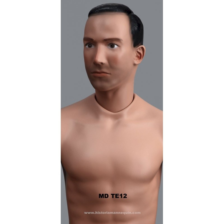

fake_mask


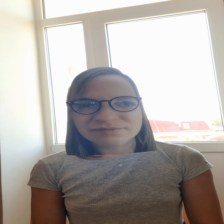

fake_printed


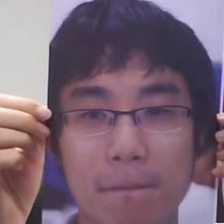

fake_screen


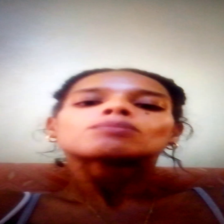

fake_unknown


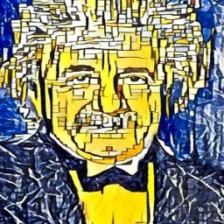

realperson


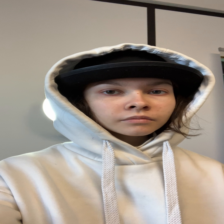

In [6]:
from IPython.display import display
from torchvision.transforms.functional import to_pil_image

num_classes = len(train_data.classes)

# Ambil satu batch
images, labels = next(iter(train_loader))

# Kelompokkan berdasarkan label
unique_labels = {}
for img, label in zip(images, labels):
    label_idx = label.item()
    if label_idx not in unique_labels:
        unique_labels[label_idx] = img
    if len(unique_labels) == num_classes:
        break

# Tampilkan 1 gambar per class (tanpa matplotlib)
for idx in range(num_classes):
    if idx in unique_labels:
        print(train_data.classes[idx])
        display(to_pil_image(unique_labels[idx]))

# Load Dataset (TIOK)

In [ ]:

def load_train_dataset(train_path, limit=None):
    """
    Load dataset train (multiclass folder)

    Parameter:
        train_path: path ke folder train
        limit: max gambar per class (None = semua)

    Return:
        image_paths: list path gambar
        labels: list label_id
        label_to_id: mapping label -> int
    """

    train_path = Path(train_path)

    class_dirs = sorted([d for d in train_path.iterdir() if d.is_dir()])

    label_to_id = {cls.name: idx for idx, cls in enumerate(class_dirs)}

    image_paths = []
    labels = []

    for cls in class_dirs:
        label_name = cls.name
        label_id = label_to_id[label_name]

        image_files = (
            list(cls.glob("*.jpg")) +
            list(cls.glob("*.png")) +
            list(cls.glob("*.jpeg"))
        )

        if limit:
            image_files = image_files[:limit]

        for img_path in image_files:
            image_paths.append(str(img_path))
            labels.append(label_id)

    return image_paths, labels, label_to_id

In [ ]:
def load_test_dataset(test_path):
    """
    Load dataset test (tanpa label)

    Parameter:
        test_path: path ke folder test

    Return:
        image_paths: list path gambar
        image_ids: nama file (untuk submission)
    """

    test_path = Path(test_path)

    image_files = (
        list(test_path.glob("*.jpg")) +
        list(test_path.glob("*.png")) +
        list(test_path.glob("*.jpeg"))
    )

    image_paths = [str(p) for p in image_files]
    image_ids = [p.stem for p in image_files]  # nama tanpa extension

    return image_paths, image_ids

In [ ]:

def build_train_df(image_paths, labels):
    return pd.DataFrame({
        "path": image_paths,
        "label": labels
    })

def build_test_df(image_paths, image_ids):
    return pd.DataFrame({
        "path": image_paths,
        "id": image_ids
    })

coba

In [ ]:
train_paths, train_labels, label_map = load_train_dataset(
    train_path="/content/drive/MyDrive/DATASET/data-analytics-competition-dac-find-it-2026/train",
    limit=None
)

test_paths, test_ids = load_test_dataset(
    test_path="/content/drive/MyDrive/DATASET/data-analytics-competition-dac-find-it-2026/test"
)

train_df = build_train_df(train_paths, train_labels)
test_df  = build_test_df(test_paths, test_ids)

print(label_map)
print(train_df.head())
print(test_df.head())

{'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}
                                                path  label
0  /content/drive/MyDrive/DATASET/data-analytics-...      0
1  /content/drive/MyDrive/DATASET/data-analytics-...      0
2  /content/drive/MyDrive/DATASET/data-analytics-...      0
3  /content/drive/MyDrive/DATASET/data-analytics-...      0
4  /content/drive/MyDrive/DATASET/data-analytics-...      0
                                                path        id
0  /content/drive/MyDrive/DATASET/data-analytics-...  test_004
1  /content/drive/MyDrive/DATASET/data-analytics-...  test_005
2  /content/drive/MyDrive/DATASET/data-analytics-...  test_003
3  /content/drive/MyDrive/DATASET/data-analytics-...  test_001
4  /content/drive/MyDrive/DATASET/data-analytics-...  test_008


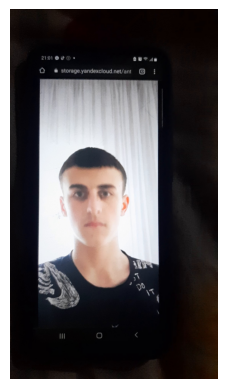

In [ ]:

def show_image(path):
    img = Image.open(path).convert("RGB")
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# contoh
show_image(train_df.loc[700, "path"])

In [ ]:
train_df.tail(700)

,path,label
738,/content/drive/MyDrive/DATASET/data-analytics-...,4
739,/content/drive/MyDrive/DATASET/data-analytics-...,4
740,/content/drive/MyDrive/DATASET/data-analytics-...,4
741,/content/drive/MyDrive/DATASET/data-analytics-...,4
742,/content/drive/MyDrive/DATASET/data-analytics-...,4
...,...,...
1433,/content/drive/MyDrive/DATASET/data-analytics-...,5
1434,/content/drive/MyDrive/DATASET/data-analytics-...,5
1435,/content/drive/MyDrive/DATASET/data-analytics-...,5
1436,/content/drive/MyDrive/DATASET/data-analytics-...,5


# Deteksi Wajah

In [7]:
# def detect_and_crop_face(
#     image_path,
#     model,
#     conf=0.3,
#     pad=0.1,
#     target_size=None,
#     fallback=True
# ):
#     """
#     Detect dan crop wajah dari gambar

#     Parameter:
#         image_path: path gambar
#         model: YOLO model
#         conf: confidence threshold
#         pad: margin bbox (0.1 = 10%)
#         target_size: resize (misal (224,224))
#         fallback: jika gagal detect, pakai full image

#     Return:
#         cropped_face (numpy array)
#     """

#     img = cv2.imread(image_path)
#     h, w, _ = img.shape

#     results = model(img, conf=conf, verbose=False)[0]

#     # tidak ada deteksi
#     if len(results.boxes) == 0:
#         if fallback:
#             face = img
#         else:
#             return None
#     else:
#         # ambil bbox terbesar (best practice untuk face)
#         boxes = results.boxes.xyxy.cpu().numpy()

#         areas = (boxes[:,2] - boxes[:,0]) * (boxes[:,3] - boxes[:,1])
#         idx = np.argmax(areas)

#         x1, y1, x2, y2 = boxes[idx]

#         # tambah padding
#         bw = x2 - x1
#         bh = y2 - y1

#         x1 = int(max(0, x1 - pad * bw))
#         y1 = int(max(0, y1 - pad * bh))
#         x2 = int(min(w, x2 + pad * bw))
#         y2 = int(min(h, y2 + pad * bh))

#         face = img[y1:y2, x1:x2]

#     # resize opsional
#     if target_size:
#         face = cv2.resize(face, target_size)

#     return face

# RetinaFace
def detect_and_crop_retinaface(image_path, margin=0.2):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    detections = RetinaFace.detect_faces(img_rgb)

    if isinstance(detections, dict):
        key = list(detections.keys())[0]
        face = detections[key]['facial_area']
        
        x1, y1, x2, y2 = face
        
        h, w, _ = img.shape
        
        # 🔥 Tambahkan margin
        dx = int((x2 - x1) * margin)
        dy = int((y2 - y1) * margin)

        x1 = max(0, x1 - dx)
        y1 = max(0, y1 - dy)
        x2 = min(w, x2 + dx)
        y2 = min(h, y2 + dy)

        cropped = img[y1:y2, x1:x2]
        return cropped
    
    return None

In [8]:
# def process_dataset(df, save_dir, model):
#     os.makedirs(save_dir, exist_ok=True)

#     new_paths = []

#     for i, row in tqdm(df.iterrows(), total=len(df)):
#         img_path = row["path"]

#         face = detect_and_crop_face(
#             img_path,
#             model=model,
#             pad=0.15,
#             target_size=(224,224)
#         )

#         save_path = os.path.join(save_dir, f"{i}.jpg")
#         cv2.imwrite(save_path, face)

#         new_paths.append(save_path)

#     df["face_path"] = new_paths
#     return df

# INPUT_DIR = "dataset/train"
# OUTPUT_DIR = "dataset_cropped/train"

INPUT_DIR = "dataset/test"
OUTPUT_DIR = "dataset_cropped/test"

def safe_detect_and_crop_retinaface(image_path, margin=0.2):
    try:
        return detect_and_crop_retinaface(image_path, margin=margin)
    except ValueError as e:
        # fallback untuk error kompatibilitas TensorFlow/Keras (KerasTensor)
        if "KerasTensor cannot be used as input to a TensorFlow function" in str(e):
            return cv2.imread(image_path)
        return cv2.imread(image_path)
    except OSError as e:
        # fallback untuk error file model RetinaFace rusak / bukan HDF5 valid
        if "file signature not found" in str(e):
            return cv2.imread(image_path)
        return cv2.imread(image_path)
    except Exception:
        return cv2.imread(image_path)

def ensure_valid_image(img, fallback_path):
    if img is None:
        return cv2.imread(fallback_path)
    if hasattr(img, "size") and img.size == 0:
        return cv2.imread(fallback_path)
    return img

os.makedirs(OUTPUT_DIR, exist_ok=True)

for entry in os.listdir(INPUT_DIR):
    src_path = os.path.join(INPUT_DIR, entry)

    # Case 1: train-like structure (class folders)
    if os.path.isdir(src_path):
        dst_class_dir = os.path.join(OUTPUT_DIR, entry)
        os.makedirs(dst_class_dir, exist_ok=True)

        for img_name in os.listdir(src_path):
            img_path = os.path.join(src_path, img_name)
            if not os.path.isfile(img_path):
                continue

            cropped = safe_detect_and_crop_retinaface(img_path, margin=0.2)
            cropped = ensure_valid_image(cropped, img_path)
            if cropped is None:
                continue

            save_path = os.path.join(dst_class_dir, img_name)
            cv2.imwrite(save_path, cropped)

    # Case 2: test-like structure (flat image files)
    elif os.path.isfile(src_path):
        cropped = safe_detect_and_crop_retinaface(src_path, margin=0.2)
        cropped = ensure_valid_image(cropped, src_path)
        if cropped is None:
            continue

        save_path = os.path.join(OUTPUT_DIR, entry)
        cv2.imwrite(save_path, cropped)

print("Face cropping selesai. Cek folder:", OUTPUT_DIR)

Face cropping selesai. Cek folder: dataset_cropped/test


coba

In [22]:
face_paths = []

for _, row in tqdm(train_data.iterrows(), total=len(train_data)):
    src_path = row["path"]
    class_name = Path(src_path).parent.name

    dst_dir = os.path.join(OUTPUT_DIR, class_name)
    os.makedirs(dst_dir, exist_ok=True)

    dst_path = os.path.join(dst_dir, Path(src_path).name)

    if not os.path.exists(dst_path):
        cropped = safe_detect_and_crop_retinaface(src_path, margin=0.2)
        if cropped is None:
            cropped = cv2.imread(src_path)
        cv2.imwrite(dst_path, cropped)

    face_paths.append(dst_path)

train_data["face_path"] = face_paths
train_data.head()

AttributeError: 'ImageFolder' object has no attribute 'iterrows'

In [23]:
train_data.head()

AttributeError: 'ImageFolder' object has no attribute 'head'

# Augmentasi

In [7]:
train_df = train_data

In [8]:
# Convert ImageFolder -> DataFrame agar bisa dipakai .head(), split stratify, dan FaceDataset
train_df = pd.DataFrame(train_data.samples, columns=["face_path", "label"])

with pd.option_context(
    "display.max_colwidth", None,
    "display.max_columns", None,
    "display.width", None
):
    display(train_df.head())


,face_path,label
0,d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset_cropped\train\fake_mannequin\mannequin_001.jpg,0
1,d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset_cropped\train\fake_mannequin\mannequin_002.jpg,0
2,d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset_cropped\train\fake_mannequin\mannequin_003.jpg,0
3,d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset_cropped\train\fake_mannequin\mannequin_004.jpg,0
4,d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset_cropped\train\fake_mannequin\mannequin_005.jpg,0


In [9]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],  # penting biar balance
    random_state=42
)

In [10]:
train_tf = T.Compose([
    T.Resize((224,224)),

    # spatial
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),

    # photometric
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1,
        hue=0.05
    ),

    # noise
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),

    T.ToTensor(),  # ← koma di sini
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_tf = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),  # ← koma di sini
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
class FaceDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["face_path"]).convert("RGB")
        label = row["label"]

        if self.transform:
            img = self.transform(img)

        return img, label

In [12]:
train_ds = FaceDataset(train_df, transform=train_tf)
val_ds   = FaceDataset(val_df, transform=val_tf)

In [13]:
print(len(train_df), len(val_df))
print(train_df["label"].value_counts())
print(val_df["label"].value_counts())

1175 294
label
5    327
4    247
1    202
0    167
3    155
2     77
Name: count, dtype: int64
label
5    82
4    62
1    50
0    42
3    39
2    19
Name: count, dtype: int64


data louder

In [14]:
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=0,          # ← PENTING: 0 untuk Windows!
    pin_memory=True         # ← PENTING: True untuk GPU
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=0,          # ← PENTING: 0 untuk Windows!
    pin_memory=True         # ← PENTING: True untuk GPU
)

# modelling

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model(
    "efficientnet_b4",
    pretrained=True,
    num_classes=6
).to(device)

In [16]:
criterion = nn.CrossEntropyLoss()

In [17]:
import torch.optim as optim

optimizer = optim.AdamW(model.parameters(), lr=1e-4)

In [18]:
def train_one_epoch(model, loader, return_preds=False):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    if return_preds:
        return total_loss, all_preds, all_labels
    return total_loss

In [19]:
def validate(model, loader, return_preds=False):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    if return_preds:
        return total_loss, all_preds, all_labels
    return total_loss

In [20]:
from sklearn.metrics import f1_score, accuracy_score

epochs = 20
best_f1 = 0  # 🔥 ganti dari acc ke f1

print(f"Training on device: {device}")
print(f"Model on GPU: {next(model.parameters()).is_cuda}")

for epoch in range(epochs):
    torch.cuda.empty_cache()
    
    train_loss, train_preds, train_labels = train_one_epoch(model, train_loader, return_preds=True)
    val_loss, val_preds, val_labels = validate(model, val_loader, return_preds=True)

    # 🔥 Hitung metric
    train_acc = accuracy_score(train_labels, train_preds)
    val_acc = accuracy_score(val_labels, val_preds)

    train_f1 = f1_score(train_labels, train_preds, average='macro')
    val_f1 = f1_score(val_labels, val_preds, average='macro')

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

    if torch.cuda.is_available():
        print(f"GPU Memory Used: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
        print(f"GPU Memory Reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
    
    # 🔥 SIMPAN BERDASARKAN F1 (PENTING!)
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "best_model.pth")
        print(f"✅ Best model saved! F1: {best_f1:.4f}")

Training on device: cuda
Model on GPU: True

Epoch 1
Train Loss: 58.3079 | Acc: 0.4187 | F1: 0.3881
Val Loss  : 12.6245 | Acc: 0.5680 | F1: 0.4883
GPU Memory Used: 0.29 GB
GPU Memory Reserved: 7.44 GB
✅ Best model saved! F1: 0.4883

Epoch 2
Train Loss: 31.2256 | Acc: 0.6962 | F1: 0.6674
Val Loss  : 9.1280 | Acc: 0.6667 | F1: 0.6009
GPU Memory Used: 0.29 GB
GPU Memory Reserved: 7.54 GB
✅ Best model saved! F1: 0.6009

Epoch 3
Train Loss: 21.0900 | Acc: 0.8077 | F1: 0.7968
Val Loss  : 7.5888 | Acc: 0.7279 | F1: 0.7091
GPU Memory Used: 0.29 GB
GPU Memory Reserved: 7.54 GB
✅ Best model saved! F1: 0.7091

Epoch 4
Train Loss: 14.7594 | Acc: 0.8783 | F1: 0.8709
Val Loss  : 6.9210 | Acc: 0.7755 | F1: 0.7549
GPU Memory Used: 0.29 GB
GPU Memory Reserved: 7.54 GB
✅ Best model saved! F1: 0.7549

Epoch 5
Train Loss: 10.8631 | Acc: 0.9191 | F1: 0.9163
Val Loss  : 6.3610 | Acc: 0.7823 | F1: 0.7552
GPU Memory Used: 0.29 GB
GPU Memory Reserved: 7.54 GB
✅ Best model saved! F1: 0.7552

Epoch 6
Train Loss:

# To Submit

In [21]:
import torch
import timm

device = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model(
    "efficientnet_b4",
    pretrained=False,
    num_classes=6
)

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)
model.eval()

EfficientNet(
  (conv_stem): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
        (bn1): BatchNormAct2d(
          48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(48, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (b

In [22]:
import torchvision.transforms as T

test_tf = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [23]:
from torch.utils.data import Dataset
from PIL import Image

class TestDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["face_path"]).convert("RGB")
        img_id = row["id"]

        if self.transform:
            img = self.transform(img)

        return img, img_id

In [30]:
# Face crop untuk TEST dataset
TEST_OUTPUT_DIR = "dataset_cropped/test"
os.makedirs(TEST_OUTPUT_DIR, exist_ok=True)

print("Melakukan face cropping pada test data...")

# Pastikan test_df tersedia
if "test_df" not in globals():
    if "load_test_dataset" in globals() and callable(load_test_dataset):
        test_paths, test_ids = load_test_dataset(TEST_DIR)
    else:
        # fallback jika fungsi load_test_dataset belum pernah dieksekusi
        image_files = [
            os.path.join(TEST_DIR, f)
            for f in os.listdir(TEST_DIR)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
        test_paths = image_files
        test_ids = [os.path.splitext(os.path.basename(p))[0] for p in image_files]

    if "build_test_df" in globals() and callable(build_test_df):
        test_df = build_test_df(test_paths, test_ids)
    else:
        test_df = pd.DataFrame({"path": test_paths, "id": test_ids})

test_face_paths = []

for idx, row in tqdm(test_df.iterrows(), total=len(test_df)):
    img_path = row["path"]
    img_id = row["id"]
    
    # Crop wajah
    cropped = safe_detect_and_crop_retinaface(img_path, margin=0.2)
    if cropped is None:
        cropped = cv2.imread(img_path)
    
    # Simpan
    save_path = os.path.join(TEST_OUTPUT_DIR, f"{img_id}.jpg")
    cv2.imwrite(save_path, cropped)
    
    test_face_paths.append(save_path)

test_df["face_path"] = test_face_paths

print(f"✅ Face cropping selesai! {len(test_face_paths)} images")
print(test_df.head())

Melakukan face cropping pada test data...


  0%|          | 0/404 [00:00<?, ?it/s]


NameError: name 'detect_and_crop_retinaface' is not defined

In [35]:
test_df["face_path"] = test_face_paths

NameError: name 'test_face_paths' is not defined

In [24]:
# Build test_df langsung dari folder hasil crop agar tidak bergantung ke build_test_df
test_dir = Path(TEST_DIR)

image_files = sorted(
    list(test_dir.glob("*.jpg")) +
    list(test_dir.glob("*.jpeg")) +
    list(test_dir.glob("*.png"))
)

test_df = pd.DataFrame({
    "id": [p.stem for p in image_files],
    "face_path": [str(p) for p in image_files]
})
with pd.option_context(
    "display.max_colwidth", None,
    "display.max_columns", None,
    "display.width", None
):
    display(test_df.head())

print(f"Total test images: {len(test_df)}")

,id,face_path
0,test_001,d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset_cropped\test\test_001.jpg
1,test_002,d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset_cropped\test\test_002.jpg
2,test_003,d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset_cropped\test\test_003.jpg
3,test_004,d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset_cropped\test\test_004.jpg
4,test_005,d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset_cropped\test\test_005.jpg


Total test images: 404


In [25]:
test_ds = TestDataset(test_df, transform=test_tf)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [26]:
print(test_df.columns)

Index(['id', 'face_path'], dtype='str')


In [27]:
row = test_df.iloc[0]
img = Image.open(row["face_path"]).convert("RGB")

In [28]:
import numpy as np

preds = []
ids = []

with torch.no_grad():
    for imgs, img_ids in test_loader:
        imgs = imgs.to(device)

        outputs = model(imgs)
        pred = outputs.argmax(1).cpu().numpy()

        preds.extend(pred)
        ids.extend(img_ids)

In [29]:
print(len(preds), len(ids), len(test_df))
print(set(preds))  # harus 0–5

404 404 404
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)}


In [30]:
if "label_map" in globals():
	id_to_label = {v: k for k, v in label_map.items()}
elif "train_data" in globals() and hasattr(train_data, "class_to_idx"):
	id_to_label = {v: k for k, v in train_data.class_to_idx.items()}
else:
	raise NameError("label_map is not defined and train_data.class_to_idx is unavailable.")

pred_labels = [id_to_label[int(p)] for p in preds]

In [31]:
import pandas as pd

submission = pd.DataFrame({
    "id": ids,
    "label": pred_labels
})
submission = submission.sort_values(by="id").reset_index(drop=True)

submission.to_csv("submission.csv", index=False)

In [32]:
print(submission.head())
print(submission.shape)

         id           label
0  test_001  fake_mannequin
1  test_002  fake_mannequin
2  test_003      realperson
3  test_004      realperson
4  test_005    fake_printed
(404, 2)


In [33]:
submission.tail()

,id,label
399,test_400,realperson
400,test_401,realperson
401,test_402,fake_mask
402,test_403,fake_unknown
403,test_404,fake_mannequin


# Coba Model Lain

In [66]:
train_loader = DataLoader(
    train_ds,
    batch_size=16,
    shuffle=True,
    num_workers=0,          # ← PENTING: 0 untuk Windows!
    pin_memory=True         # ← PENTING: True untuk GPU
)

val_loader = DataLoader(
    val_ds,
    batch_size=16,
    shuffle=False,
    num_workers=0,          # ← PENTING: 0 untuk Windows!
    pin_memory=True         # ← PENTING: True untuk GPU
)

In [67]:
import torch
import torch.nn as nn
import timm
from sklearn.metrics import f1_score, accuracy_score

def train_convnext(
    train_loader,
    val_loader,
    device,
    num_classes=6,
    epochs=20,
    lr=3e-5
):
    # 🔥 UPGRADE KE CONVNEXT SMALL
    model = timm.create_model(
        "convnext_small",
        pretrained=True,
        num_classes=num_classes
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_f1 = 0
    patience = 3
    counter = 0

    for epoch in range(epochs):
        print(f"\n[ConvNeXt Small] Epoch {epoch+1}")

        # ===== TRAIN =====
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            train_preds.extend(preds)
            train_labels.extend(labels.cpu().numpy())

        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average='macro')

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0
        val_preds = []
        val_labels = []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)

                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(labels.cpu().numpy())

        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average='macro')

        print(f"Train Loss: {train_loss/len(train_loader):.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"Val Loss  : {val_loss/len(val_loader):.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

        if torch.cuda.is_available():
            print(f"GPU Memory Used: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
            print(f"GPU Memory Reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

        # 🔥 SAVE BEST MODEL BASED ON F1
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "convnext_best.pth")
            print(f"✅ Best model saved! F1: {best_f1:.4f}")
            counter = 0
        else:
            counter += 1

        # 🔥 EARLY STOPPING
        if counter >= patience:
            print("⛔ Early stopping triggered!")
            break

        scheduler.step()

    return model

In [68]:
model_conv = train_convnext(train_loader, val_loader, device)


[ConvNeXt Small] Epoch 1
Train Loss: 0.6186 | Acc: 0.7838 | F1: 0.7632
Val Loss  : 0.3245 | Acc: 0.8878 | F1: 0.8865
GPU Memory Used: 1.57 GB
GPU Memory Reserved: 7.64 GB
✅ Best model saved! F1: 0.8865

[ConvNeXt Small] Epoch 2
Train Loss: 0.1516 | Acc: 0.9557 | F1: 0.9522
Val Loss  : 0.4729 | Acc: 0.8878 | F1: 0.8932
GPU Memory Used: 1.57 GB
GPU Memory Reserved: 7.64 GB
✅ Best model saved! F1: 0.8932

[ConvNeXt Small] Epoch 3
Train Loss: 0.1048 | Acc: 0.9668 | F1: 0.9653
Val Loss  : 0.3269 | Acc: 0.9014 | F1: 0.9062
GPU Memory Used: 1.57 GB
GPU Memory Reserved: 7.64 GB
✅ Best model saved! F1: 0.9062

[ConvNeXt Small] Epoch 4
Train Loss: 0.1193 | Acc: 0.9617 | F1: 0.9626
Val Loss  : 0.3935 | Acc: 0.9082 | F1: 0.9109
GPU Memory Used: 1.57 GB
GPU Memory Reserved: 7.64 GB
✅ Best model saved! F1: 0.9109

[ConvNeXt Small] Epoch 5
Train Loss: 0.0495 | Acc: 0.9838 | F1: 0.9832
Val Loss  : 0.4099 | Acc: 0.9082 | F1: 0.9067
GPU Memory Used: 1.57 GB
GPU Memory Reserved: 7.64 GB

[ConvNeXt Small

In [98]:
train_loader = DataLoader(
    train_ds,
    batch_size=16,
    shuffle=True,
    num_workers=0,          # ← PENTING: 0 untuk Windows!
    pin_memory=True         # ← PENTING: True untuk GPU
)

val_loader = DataLoader(
    val_ds,
    batch_size=16,
    shuffle=False,
    num_workers=0,          # ← PENTING: 0 untuk Windows!
    pin_memory=True         # ← PENTING: True untuk GPU
)

In [99]:
import torch
import torch.nn as nn
import timm
from sklearn.metrics import f1_score, accuracy_score

def train_vit(
    train_loader,
    val_loader,
    device,
    num_classes=6,
    epochs=20,
    lr=3e-5
):
    # 🔥 UPGRADE KE VIT BASE
    model = timm.create_model(
        "vit_base_patch16_224",
        pretrained=True,
        num_classes=num_classes
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_f1 = 0
    patience = 3
    counter = 0

    for epoch in range(epochs):
        print(f"\n[ViT Base] Epoch {epoch+1}")

        # ===== TRAIN =====
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            train_preds.extend(preds)
            train_labels.extend(labels.cpu().numpy())

        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average='macro')

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0
        val_preds = []
        val_labels = []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)

                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(labels.cpu().numpy())

        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average='macro')

        print(f"Train Loss: {train_loss/len(train_loader):.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"Val Loss  : {val_loss/len(val_loader):.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

        if torch.cuda.is_available():
            print(f"GPU Memory Used: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
            print(f"GPU Memory Reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

        # 🔥 SAVE BERDASARKAN F1
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "vit_best.pth")
            print(f"✅ Best model saved! F1: {best_f1:.4f}")
            counter = 0
        else:
            counter += 1

        # 🔥 EARLY STOPPING
        if counter >= patience:
            print("⛔ Early stopping triggered!")
            break

        scheduler.step()

    return model

In [100]:
model_vit  = train_vit(train_loader, val_loader, device)


[ViT Base] Epoch 1
Train Loss: 0.6438 | Acc: 0.7770 | F1: 0.7668
Val Loss  : 0.3618 | Acc: 0.8810 | F1: 0.8866
GPU Memory Used: 2.86 GB
GPU Memory Reserved: 7.64 GB
✅ Best model saved! F1: 0.8866

[ViT Base] Epoch 2
Train Loss: 0.1970 | Acc: 0.9438 | F1: 0.9411
Val Loss  : 0.3685 | Acc: 0.9014 | F1: 0.9104
GPU Memory Used: 2.86 GB
GPU Memory Reserved: 7.64 GB
✅ Best model saved! F1: 0.9104

[ViT Base] Epoch 3
Train Loss: 0.0940 | Acc: 0.9719 | F1: 0.9717
Val Loss  : 0.3971 | Acc: 0.8878 | F1: 0.8875
GPU Memory Used: 2.86 GB
GPU Memory Reserved: 7.64 GB

[ViT Base] Epoch 4
Train Loss: 0.0530 | Acc: 0.9838 | F1: 0.9833
Val Loss  : 0.4935 | Acc: 0.8844 | F1: 0.8884
GPU Memory Used: 2.86 GB
GPU Memory Reserved: 7.64 GB

[ViT Base] Epoch 5
Train Loss: 0.0419 | Acc: 0.9898 | F1: 0.9876
Val Loss  : 0.4193 | Acc: 0.9048 | F1: 0.9133
GPU Memory Used: 2.86 GB
GPU Memory Reserved: 7.64 GB
✅ Best model saved! F1: 0.9133

[ViT Base] Epoch 6
Train Loss: 0.0201 | Acc: 0.9915 | F1: 0.9895
Val Loss  :

In [101]:
import os

missing = test_df[~test_df["face_path"].apply(os.path.exists)]
print(len(missing))
missing.head()

0


,id,face_path


In [106]:
import torch
import torch.nn as nn
import timm

def train_resnet(
    train_loader,
    val_loader,
    device,
    num_classes=6,
    epochs=20,
    lr=1e-4
):
    model = timm.create_model(
        "resnet50",
        pretrained=True,
        num_classes=num_classes
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_acc = 0

    for epoch in range(epochs):
        print(f"\n[ResNet50] Epoch {epoch+1}")

        # ===== TRAIN =====
        model.train()
        train_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)

                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                pred = outputs.argmax(1)
                correct += (pred == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total

        print(f"Train Loss: {train_loss/len(train_loader):.4f}")
        print(f"Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.4f}")

        if torch.cuda.is_available():
            print(f"GPU Memory Used: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
            print(f"GPU Memory Reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

        # save best
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "resnet50_best.pth")
            print(f"✅ Best model saved! Accuracy: {best_acc:.4f}")

        scheduler.step()

    return model

In [107]:
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

model_resnet = train_resnet(train_loader, val_loader, device)


[ResNet50] Epoch 1
Train Loss: 1.7239
Val Loss: 1.6428 | Val Acc: 0.3810
GPU Memory Used: 1.19 GB
GPU Memory Reserved: 4.32 GB
✅ Best model saved! Accuracy: 0.3810

[ResNet50] Epoch 2
Train Loss: 1.5704
Val Loss: 1.4570 | Val Acc: 0.4830
GPU Memory Used: 1.19 GB
GPU Memory Reserved: 4.32 GB
✅ Best model saved! Accuracy: 0.4830

[ResNet50] Epoch 3
Train Loss: 1.3712
Val Loss: 1.1984 | Val Acc: 0.6088
GPU Memory Used: 1.19 GB
GPU Memory Reserved: 4.32 GB
✅ Best model saved! Accuracy: 0.6088

[ResNet50] Epoch 4
Train Loss: 1.0947
Val Loss: 0.9054 | Val Acc: 0.7177
GPU Memory Used: 1.19 GB
GPU Memory Reserved: 4.32 GB
✅ Best model saved! Accuracy: 0.7177

[ResNet50] Epoch 5
Train Loss: 0.8583
Val Loss: 0.7161 | Val Acc: 0.7857
GPU Memory Used: 1.19 GB
GPU Memory Reserved: 4.32 GB
✅ Best model saved! Accuracy: 0.7857

[ResNet50] Epoch 6
Train Loss: 0.6816
Val Loss: 0.5937 | Val Acc: 0.7993
GPU Memory Used: 1.19 GB
GPU Memory Reserved: 4.32 GB
✅ Best model saved! Accuracy: 0.7993

[ResNet50

In [258]:
import torch
import torch.nn as nn
import timm
from sklearn.metrics import f1_score, accuracy_score

def train_swin(
    train_loader,
    val_loader,
    device,
    num_classes=6,
    epochs=20,
    lr=3e-5
):
    # 🔥 UPGRADE KE SWIN SMALL
    model = timm.create_model(
        "swin_small_patch4_window7_224",
        pretrained=True,
        num_classes=num_classes
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    # 🔥 OPTIMIZER LEBIH STABIL
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    best_f1 = 0
    patience = 3
    counter = 0

    for epoch in range(epochs):
        print(f"\n[Swin Small] Epoch {epoch+1}")

        # ===== TRAIN =====
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            train_preds.extend(preds)
            train_labels.extend(labels.cpu().numpy())

        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average='macro')

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0
        val_preds = []
        val_labels = []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)

                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(labels.cpu().numpy())

        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average='macro')

        print(f"Train Loss: {train_loss/len(train_loader):.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"Val Loss  : {val_loss/len(val_loader):.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

        if torch.cuda.is_available():
            print(f"GPU Memory Used: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
            print(f"GPU Memory Reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

        # 🔥 SAVE BERDASARKAN F1
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "swin_best.pth")
            print(f"✅ Best model saved! F1: {best_f1:.4f}")
            counter = 0
        else:
            counter += 1

        # 🔥 EARLY STOPPING
        if counter >= patience:
            print("⛔ Early stopping triggered!")
            break

        scheduler.step()

    return model

In [259]:
train_loader = DataLoader(
    train_ds,
    batch_size=16,           # Swin Tiny optimal untuk GPU 6GB
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

model_swin = train_swin(train_loader, val_loader, device)


[Swin Small] Epoch 1
Train Loss: 0.9783 | Acc: 0.6630 | F1: 0.6216
Val Loss  : 0.4359 | Acc: 0.8537 | F1: 0.8314
GPU Memory Used: 3.41 GB
GPU Memory Reserved: 7.73 GB
✅ Best model saved! F1: 0.8314

[Swin Small] Epoch 2
Train Loss: 0.3092 | Acc: 0.9174 | F1: 0.9131
Val Loss  : 0.3056 | Acc: 0.9150 | F1: 0.9175
GPU Memory Used: 3.41 GB
GPU Memory Reserved: 7.73 GB
✅ Best model saved! F1: 0.9175

[Swin Small] Epoch 3
Train Loss: 0.1547 | Acc: 0.9574 | F1: 0.9564
Val Loss  : 0.3065 | Acc: 0.9082 | F1: 0.9057
GPU Memory Used: 3.41 GB
GPU Memory Reserved: 7.73 GB

[Swin Small] Epoch 4
Train Loss: 0.0943 | Acc: 0.9736 | F1: 0.9721
Val Loss  : 0.2880 | Acc: 0.9218 | F1: 0.9173
GPU Memory Used: 3.22 GB
GPU Memory Reserved: 7.73 GB

[Swin Small] Epoch 5
Train Loss: 0.0682 | Acc: 0.9830 | F1: 0.9801
Val Loss  : 0.2994 | Acc: 0.9150 | F1: 0.9100
GPU Memory Used: 3.22 GB
GPU Memory Reserved: 7.73 GB
⛔ Early stopping triggered!


# Ensamble

In [260]:
import timm
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. EfficientNet B4
model1 = timm.create_model("efficientnet_b4", pretrained=False, num_classes=6)
model1.load_state_dict(torch.load("best_model.pth"))
model1.to(device).eval()

# 2. ConvNeXt Small
model2 = timm.create_model("convnext_small", pretrained=False, num_classes=6)
model2.load_state_dict(torch.load("convnext_best.pth"))
model2.to(device).eval()

# 3. ViT Small
model3 = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=6)
model3.load_state_dict(torch.load("vit_best.pth"))
model3.to(device).eval()

# 4. ResNet50
# model4 = timm.create_model("resnet50", pretrained=False, num_classes=6)
# model4.load_state_dict(torch.load("resnet50_best.pth"))
# model4.to(device).eval()

# 5. Swin Transformer (NEW!)
model5 = timm.create_model("swin_small_patch4_window7_224", pretrained=False, num_classes=6)
model5.load_state_dict(torch.load("swin_best.pth"))
model5.to(device).eval()

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

In [261]:
import torch.nn.functional as F

preds = []
ids = []

with torch.no_grad():
    for imgs, img_ids in test_loader:
        imgs = imgs.to(device)

        out1 = model1(imgs)
        out2 = model2(imgs)
        out3 = model3(imgs)
        # out4 = model4(imgs)
        out5 = model5(imgs)

        p1 = F.softmax(out1, dim=1)
        p2 = F.softmax(out2, dim=1)
        p3 = F.softmax(out3, dim=1)
        # p4 = F.softmax(out4, dim=1)
        p5 = F.softmax(out5, dim=1)

        # prob = (p1 + p2 + p3) / 3
        prob = (p1 + p2 + p3 + p5) / 4
        pred = prob.argmax(1).cpu().numpy()

        preds.extend(pred)
        ids.extend(img_ids)

In [262]:
if "label_map" in globals():
	id_to_label = {v: k for k, v in label_map.items()}
elif "train_data" in globals() and hasattr(train_data, "class_to_idx"):
	id_to_label = {v: k for k, v in train_data.class_to_idx.items()}
else:
	raise NameError("label_map is not defined and train_data.class_to_idx is unavailable.")

pred_labels = [id_to_label[int(p)] for p in preds]

In [263]:
import pandas as pd

submission = pd.DataFrame({
    "id": ids,
    "label": pred_labels
})

In [264]:
submission = submission.sort_values("id").reset_index(drop=True)

In [265]:
submission.to_csv("submission_ensemble_4models.csv", index=False)

In [266]:
print(submission.head())
print(submission.shape)
print(set(preds))

         id           label
0  test_001     fake_screen
1  test_002  fake_mannequin
2  test_003      realperson
3  test_004      realperson
4  test_005    fake_printed
(404, 2)
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)}


# Coba Ensemble Weight

In [268]:
import numpy as np
from sklearn.metrics import f1_score

def find_best_weights(eff_probs, conv_probs, vit_probs, swin_probs, y_true):
    best_f1 = 0
    best_weights = None

    for w1 in np.arange(0.2, 0.5, 0.05):  # EfficientNet
        for w2 in np.arange(0.1, 0.4, 0.05):  # ConvNeXt
            for w3 in np.arange(0.1, 0.4, 0.05):  # ViT
                for w4 in np.arange(0.1, 0.4, 0.05):  # Swin
                    
                    if abs(w1 + w2 + w3 + w4 - 1.0) > 1e-6:
                        continue
                    
                    final_probs = (
                        w1 * eff_probs +
                        w2 * conv_probs +
                        w3 * vit_probs +
                        w4 * swin_probs
                    )

                    preds = np.argmax(final_probs, axis=1)
                    f1 = f1_score(y_true, preds, average='macro')

                    if f1 > best_f1:
                        best_f1 = f1
                        best_weights = (w1, w2, w3, w4)

    print("🔥 Best F1:", best_f1)
    print("🔥 Best Weights:", best_weights)

    return best_weights

In [269]:
def get_probs(model, loader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)

            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1).cpu().numpy()

            all_probs.append(probs)
            all_labels.extend(labels.numpy())

    return np.vstack(all_probs), np.array(all_labels)

In [271]:
eff_probs, y_val = get_probs(model1, val_loader, device)
conv_probs, _    = get_probs(model2, val_loader, device)
vit_probs, _     = get_probs(model3, val_loader, device)
swin_probs, _    = get_probs(model5, val_loader, device)

In [272]:
best_w = find_best_weights(
    eff_probs,
    conv_probs,
    vit_probs,
    swin_probs,
    y_val
)

🔥 Best F1: 0.9405702837914617
🔥 Best Weights: (np.float64(0.35), np.float64(0.25000000000000006), np.float64(0.1), np.float64(0.30000000000000004))


In [273]:
import torch
import torch.nn.functional as F
import pandas as pd

def ensemble_predict_optimized(test_loader, model1, model2, model3, model5, device, label_map, weights):
    for model in [model1, model2, model3, model5]:
        model.eval()

    preds = []
    ids = []

    w1, w2, w3, w4 = weights

    with torch.no_grad():
        for imgs, img_ids in test_loader:
            imgs = imgs.to(device)

            out1 = model1(imgs)
            out2 = model2(imgs)
            out3 = model3(imgs)
            out5 = model5(imgs)

            p1 = F.softmax(out1, dim=1)
            p2 = F.softmax(out2, dim=1)
            p3 = F.softmax(out3, dim=1)
            p5 = F.softmax(out5, dim=1)

            prob = w1 * p1 + w2 * p2 + w3 * p3 + w4 * p5
            pred = prob.argmax(1).cpu().numpy()

            preds.extend(pred)
            ids.extend(img_ids)

    id_to_label = {v: k for k, v in label_map.items()}
    pred_labels = [id_to_label[int(p)] for p in preds]

    submission = pd.DataFrame({
        "id": ids,
        "label": pred_labels
    }).sort_values("id").reset_index(drop=True)

    return submission

In [274]:
# fallback jika label_map belum ada
if "label_map" in globals():
    _label_map = label_map
elif "train_data" in globals() and hasattr(train_data, "class_to_idx"):
    _label_map = train_data.class_to_idx
else:
    raise NameError("label_map tidak ditemukan dan train_data.class_to_idx juga tidak tersedia.")

# Jalankan ensemble
submission = ensemble_predict_optimized(
    test_loader,
    model1, model2, model3,model5,
    device,
    _label_map,
    best_w
)

submission.to_csv("submission_ensemble_4models_weighted.csv", index=False)

In [275]:
print(submission.head())

         id           label
0  test_001     fake_screen
1  test_002  fake_mannequin
2  test_003      realperson
3  test_004      realperson
4  test_005    fake_printed


# TTA + Ensemble


In [290]:
import torchvision.transforms as T

tta_transforms = [
    T.Compose([]),  # original
    T.Compose([T.RandomHorizontalFlip(p=1.0)]),
    T.Compose([T.ColorJitter(brightness=0.2, contrast=0.2)]),
]

In [291]:
import torch
import torch.nn.functional as F
import pandas as pd

def ensemble_predict_tta(
    test_loader,
    model1, model2, model3, model5,
    device,
    label_map,
    weights
):
    for model in [model1, model2, model3, model5]:
        model.eval()

    preds = []
    ids = []

    w1, w2, w3, w4 = weights

    with torch.no_grad():
        for imgs, img_ids in test_loader:
            imgs = imgs.to(device)

            # 🔥 list untuk simpan semua TTA prediction
            tta_probs = []

            for tta_idx in range(3):
                if tta_idx == 1:
                    aug_imgs = torch.flip(imgs, dims=[3])  # horizontal flip
                elif tta_idx == 2:
                    aug_imgs = imgs * 1.1  # brightness simple
                    aug_imgs = torch.clamp(aug_imgs, 0, 1)
                else:
                    aug_imgs = imgs

                out1 = model1(aug_imgs)
                out2 = model2(aug_imgs)
                out3 = model3(aug_imgs)
                out5 = model5(aug_imgs)

                p1 = F.softmax(out1, dim=1)
                p2 = F.softmax(out2, dim=1)
                p3 = F.softmax(out3, dim=1)
                p5 = F.softmax(out5, dim=1)

                prob = w1*p1 + w2*p2 + w3*p3 + w4*p5
                tta_probs.append(prob)

            # 🔥 rata-rata semua TTA
            final_prob = torch.stack(tta_probs).mean(dim=0)

            pred = final_prob.argmax(1).cpu().numpy()

            preds.extend(pred)
            ids.extend(img_ids)

    id_to_label = {v: k for k, v in label_map.items()}
    pred_labels = [id_to_label[int(p)] for p in preds]

    submission = pd.DataFrame({
        "id": ids,
        "label": pred_labels
    }).sort_values("id").reset_index(drop=True)

    return submission

In [293]:
# fallback jika label_map belum ada
if "label_map" in globals():
    _label_map = label_map
elif "train_data" in globals() and hasattr(train_data, "class_to_idx"):
    _label_map = train_data.class_to_idx
else:
    raise NameError("label_map tidak ditemukan dan train_data.class_to_idx juga tidak tersedia.")

submission = ensemble_predict_tta(
    test_loader,
    model1,
    model2,
    model3,
    model5,
    device,
    _label_map,
    best_w
)

submission.to_csv("submission_tta.csv", index=False)

# Cek Ground Truth

In [ ]:
import pandas as pd

sub = pd.read_csv("submission_2models_ensemble_tta.csv")      # hasil prediksi
gt  = pd.read_csv("ground_truth.csv")    # label benar

In [55]:
print(sub.head())
print(gt.head())

         id           label
0  test_001     fake_screen
1  test_002  fake_mannequin
2  test_003      realperson
3  test_004      realperson
4  test_005    fake_printed
         id           label  Unnamed: 2 Unnamed: 3
0  test_001     fake_screen         NaN        NaN
1  test_002  fake_mannequin         NaN        NaN
2  test_003      realperson         NaN        NaN
3  test_004      realperson         NaN        NaN
4  test_005    fake_printed         NaN        NaN


In [56]:
gt = gt[['id', 'label']]

In [57]:
df_eval = sub.merge(gt, on="id", suffixes=("_pred", "_true"))

In [58]:
acc = (df_eval["label_pred"] == df_eval["label_true"]).mean()
print("Accuracy:", acc)

Accuracy: 0.9232673267326733


Catatan :
1. crop Yolo, ensemble Efficientnet_convnext_ViT dengan soft Voting 1/3
Accuracy: 0.9207920792079208

2. crop Yolo, ensemble Efficientnet_convnext_ViT dengan Weight 2,4,4
Accuracy: 0.9207920792079208

3. crop Yolo, ensemble Efficientnet_convnext_ViT dengan Weight 2, 4.5 , 3.5
(Accuracy: 0.91)

4. crop Yolo, ensemble Efficientnet_convnext_ViT dengan Weight 2, 3 , 5
(Accuracy: 0.9232673267326733)

5. 226 sama

6. 118 Accuracy: 0.905940594059406

7. RetinaFace, ensemble weight 235, Accuracy: 0.9108910891089109

8. RetinaFace, Accuracy: 0.905940594059406

9. 5  models + weigth , Accuracy: 0.9158415841584159

10. 5  models + weigth 0.30, 0.25, 0.15, 0.10, 0.20 , Accuracy: 0.9183168316831684 (submission_ensemble_5models_with_swin.csv)

11. submission_ensemble_RetinaFace_5models_b4_convsmall.csv Accuracy: 0.9232673267326733

12. submission_ensemble_5models_with_swin_b4_convsmall_vbase.csv Accuracy: 0.9306930693069307

13. submission_ensemble_RetinaFace_4models_b4_convsmall_vbase.csv Accuracy: 0.9306930693069307

In [50]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df_eval["label_true"],
    df_eval["label_pred"]
)

print(cm)

[[45  0  0  0  0  0]
 [ 4 64  0  0  1  1]
 [ 1  1 55  0  1  5]
 [ 1  0  0 65  3  4]
 [ 2  1  0  0 46  0]
 [ 0  4  0  1  1 98]]


In [51]:
from sklearn.metrics import classification_report

print(classification_report(
    df_eval["label_true"],
    df_eval["label_pred"]
))

                precision    recall  f1-score   support

fake_mannequin       0.85      1.00      0.92        45
     fake_mask       0.91      0.91      0.91        70
  fake_printed       1.00      0.87      0.93        63
   fake_screen       0.98      0.89      0.94        73
  fake_unknown       0.88      0.94      0.91        49
    realperson       0.91      0.94      0.92       104

      accuracy                           0.92       404
     macro avg       0.92      0.93      0.92       404
  weighted avg       0.93      0.92      0.92       404



In [52]:
wrong = df_eval[df_eval["label_pred"] != df_eval["label_true"]]
print(wrong.head())
print(wrong.shape)
wrong.to_csv("wrong.csv", index=False)

          id      label_pred    label_true
23  test_024    fake_unknown   fake_screen
30  test_031      realperson  fake_printed
48  test_049       fake_mask  fake_printed
64  test_065      realperson     fake_mask
89  test_090  fake_mannequin     fake_mask
(31, 3)
